#  **Preprocessing**

In [0]:
import pandas as pd

# Import our synthetic dataset from GitHub repo
raw_url = "https://raw.githubusercontent.com/jazz1416/VetTrack-Customer-Service-Agent/refs/heads/main/synthetic_customer_support_tickets.csv"
df = pd.read_csv(raw_url)
df = df[df['Ticket Status'] == 'Closed']

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Minutes to resolve
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,7/14/20,Client Communication (Email/SMS),SMS Reminders Not Sending,We've noticed that SMS reminders for upcoming ...,Closed,We conducted a thorough investigation and foun...,Critical,Social media,6/1/23 11:14,6/1/23 18:05,3.0,120.0
1,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,11/13/20,Client Communication (Email/SMS),SMS Reminders Not Sending,Clients have reported that they are not receiv...,Closed,"After analyzing the system logs, we discovered...",Critical,Social media,6/1/23 7:29,6/1/23 1:57,3.0,90.0
2,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2/4/20,Client Communication (Email/SMS),SMS Reminders Not Sending,The SMS reminders for pet vaccinations are fai...,Closed,The issue was traced back to a software update...,Critical,Email,6/1/23 0:12,6/1/23 19:53,1.0,150.0
3,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,1/19/21,Client Communication (Email/SMS),SMS Reminders Not Sending,We're experiencing an issue where no SMS remin...,Closed,"Upon review, we found a server-side script fai...",Critical,Phone,6/1/23 17:46,5/31/23 23:51,1.0,110.0
4,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,10/24/21,Client Communication (Email/SMS),SMS Reminders Not Sending,All SMS reminders for our upcoming appointment...,Closed,The SMS queue was overloaded due to a bug in t...,Critical,Chat,6/1/23 12:05,6/1/23 9:27,1.0,130.0


In [0]:
# Get columns that contain n/a values
df.columns[df.isna().any()].tolist()

[]

In [0]:
import pandas as pd

# Cast columns to proper data types
df['Ticket ID'] = df['Ticket ID'].astype('int64')
df['Customer Name'] = df['Customer Name'].astype('string')
df['Customer Email'] = df['Customer Email'].astype('string')
df['Customer Age'] = df['Customer Age'].astype('int64')
df['Customer Gender'] = df['Customer Gender'].astype('string')
df['Product Purchased'] = df['Product Purchased'].astype('string')
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%m/%d/%y')
df['Ticket Type'] = df['Ticket Type'].astype('string')
df['Ticket Subject'] = df['Ticket Subject'].astype('string')
df['Ticket Description'] = df['Ticket Description'].astype('string')
df['Ticket Status'] = df['Ticket Status'].astype('string')
df['Resolution'] = df['Resolution'].astype('string')
df['Ticket Priority'] = df['Ticket Priority'].astype('string')
df['Ticket Channel'] = df['Ticket Channel'].astype('string')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%m/%d/%y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%m/%d/%y %H:%M')
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].astype('int64')
df['Minutes to resolve'] = df['Minutes to resolve'].astype('Int64')

In [0]:
import re

# Text normalization 
def normalize_text(text):
    text = str(text).lower() # str() prevents errors on nulls
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['Ticket Description'] = df['Ticket Description'].apply(normalize_text)
df['Resolution'] = df['Resolution'].apply(normalize_text)

print(f"Filtered down to {len(df)} closed tickets for training.")

Filtered down to 2769 closed tickets for training.


In [0]:
# Columns that should be categorized
cat_cols = ['Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority']

# Create a new column with int values for each category 
for col in cat_cols:
    numerical_values, _ = pd.factorize(df[col])
    current_index = df.columns.get_loc(col)
    new_col_name = f'{col}_id'
    df.insert(current_index + 1, column = new_col_name, value = numerical_values)

In [0]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.4/426.4 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.6/444.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.1/221.1 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 141.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.5/188.5 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 148.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 173.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 161.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

# Map to the new description column
texts = df['Ticket Description'].tolist()

batch_size = 1000
embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True)

df['embeddings'] = list(embeddings)
print(f"Created embeddings with shape: {embeddings.shape}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-27e83b88-f435-4967-bb51-c869c2dea937/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Created embeddings with shape: (2769, 384)


In [0]:
# Create the default catalog and schema if they don't already exist
spark.sql("CREATE CATALOG IF NOT EXISTS main")
spark.sql("CREATE SCHEMA IF NOT EXISTS main.default")

DataFrame[]

In [0]:
# Unity Catalog location: catalog.schema.table
catalog = "main"
schema = "default"
table_name = "final_project_data"

# Rename columns to replace spaces with underscores 
df.columns = df.columns.str.replace(' ', '_')

# Convert Pandas DataFrame to Spark and write as Delta
# mode("overwrite") replaces the table if it exists (good for re-running the lab)
final_project_data = spark.createDataFrame(df)
final_project_data.write.format("delta").mode("overwrite").saveAsTable(f"{catalog}.{schema}.{table_name}")

# Verify: query the table
display(spark.table(f"{catalog}.{schema}.{table_name}").limit(5))

Ticket_ID Customer_Name Customer_Email Customer_Age Customer_Gender Product_Purchased Date_of_Purchase Ticket_Type Ticket_Type_id Ticket_Subject Ticket_Subject_id Ticket_Description Ticket_Status Ticket_Status_id Resolution Ticket_Priority Ticket_Priority_id Ticket_Channel First_Response_Time Time_to_Resolution Customer_Satisfaction_Rating Minutes_to_resolve embeddings 5685 Tony Mitchell rachel87@example.org 22 Male Google Pixel 2020-03-19T00:00:00.000Z Billing and Invoicing 4 Payment Gateway Failure 14 payment processing has completely failed and no transactions can be completed this urgently needs to be resolved to avoid losing clients Closed 0 the issue was linked to a recent software update that conflicted with the payment gateway api rolled back the update and confirmed that payment processing is now functioning normally Critical 0 Chat 2023-06-01T17:35:00.000Z 2023-06-01T08:03:00.000Z 4 160 List(-0.017343579, 0.033249114, -0.0064769867, -0.054143827, -0.048724696, -0.01393343, -0.061776992, -0.038859252, -0.013986541, 0.039344776, 0.06232592, -0.04040516, 0.010672924, 0.03057162, 0.006598649, -0.034182545, -0.0038358697, -0.038268577, 0.005579872, 0.03765739, -0.12611836, 0.022171907, -0.09007709, -0.013885759, -0.04898789, 0.01784369, -0.0071407557, -0.08559797, -0.002013298, 0.027248936, 0.066923, 0.042165246, -0.014178665, -0.03541737, 0.09810046, 0.054908942, -0.0071877777, -0.03197677, 0.015077168, -0.051714458, 0.038090583, -0.029490482, -0.056344595, 0.015672386, 0.097078934, 0.009377298, 0.03583445, -0.049844865, 0.0030638743, -0.0023432593, -0.08384404, -0.041433115, -0.007273001, 0.06986863, -0.022768382, -0.045181904, 0.022766583, 0.020578448, -0.011735895, -0.05553698, 0.029847823, 0.052059997, -0.04457183, -0.0067818887, 0.062370293, 0.060408685, 0.018247675, -0.057181273, -0.0150062945, 0.05806874, 0.05728782, -0.042494442, -0.0794619, 0.05313876, -0.055743918, 0.019450407, 0.0030367665, -0.002837161, 0.0029415423, 0.07729975, -0.007460341, -0.07755382, -0.05522871, -0.020440577, -0.019598661, 0.039328586, -0.06470423, -0.010578044, -0.025065837, -0.07174941, -0.03153179, 0.16052134, 0.0057118596, -0.09311745, 0.04122021, -0.024597175, 0.0810162, -1.4913895E-5, -0.03526525, 0.0079405885, 0.033541474, 0.048338983, 0.036338635, -0.01307243, -0.018749822, 0.07018041, 0.012349908, 0.054065734, -0.019300587, -0.058191843, -0.085777305, -0.042533953, 0.030374084, -0.019509906, 0.025086474, 0.058539066, -0.045571133, 0.01157809, -0.0229551, 0.05595658, -0.07226197, 0.08899399, -0.07917755, -0.07396113, 0.012339045, 0.016774295, 0.09645256, 8.545215E-35, -0.0111153005, -0.013830623, -0.023801325, -0.0343163, 0.047627844, 0.021499295, 0.068770744, -0.0026444292, 0.014735942, -0.045766383, 0.03135559, -0.12175285, 0.0048006023, -0.060061894, -0.036770023, -0.08458548, 0.09026645, 0.049506925, 0.0385232, 0.0859599, 0.009412861, -0.046979934, 0.049542088, 0.032685623, -0.012240859, 0.031169573, 0.044943105, 0.012915131, 0.085807934, -0.015093706, 0.046132673, 0.022480516, 0.020134976, 0.0559469, -0.10506884, 0.027173014, -0.0107341325, -0.0066596363, -0.0066367686, -0.070007145, -0.07486559, 0.042284653, -0.016864276, 0.0059577054, -0.025351424, 0.020222284, 0.021473125, -0.031042147, 0.017597523, 0.12049156, -0.031679988, 0.014580442, -0.055323087, -0.01435542, -0.017290236, 0.0069242455, 0.004843414, -0.030355005, -0.08593575, -0.093702056, 0.031106332, -0.11236212, -0.07656166, -0.04947183, 0.056129485, -0.065908425, -0.032622065, -0.06060256, -0.029126836, -0.057222232, -0.04087622, 0.027523039, 0.20296992, 0.0060247174, 0.010596288, -0.033382688, -0.033697765, -0.046663113, 0.010022431, 0.025658902, -0.07587298, -0.021279912, 0.029444601, -0.047404226, 0.051261045, 0.13803084, 0.05391137, 0.014686239, -0.05581395, 0.011028934, -0.027474111, 0.02672642, -0.04918546, 0.006727558, 0.12861475, -1.7500268E-33, -0.048911717, -0.04221273, -0.11594915, 0.07593805, 0.01718334, 0.012644542, -0.01600591, 0.022852167, 0.07504

# Exploratory Data **Analysis**

### Dataset Overview

In [0]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2769
Columns: 23


In [0]:
#column types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2769 entries, 0 to 2768
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket_ID                     2769 non-null   int64         
 1   Customer_Name                 2769 non-null   string        
 2   Customer_Email                2769 non-null   string        
 3   Customer_Age                  2769 non-null   int64         
 4   Customer_Gender               2769 non-null   string        
 5   Product_Purchased             2769 non-null   string        
 6   Date_of_Purchase              2769 non-null   datetime64[ns]
 7   Ticket_Type                   2769 non-null   string        
 8   Ticket_Type_id                2769 non-null   int64         
 9   Ticket_Subject                2769 non-null   string        
 10  Ticket_Subject_id             2769 non-null   int64         
 11  Ticket_Description            2769 

In [0]:
#summary stats
df.describe()

,Ticket_ID,Customer_Age,Date_of_Purchase,Ticket_Type_id,Ticket_Subject_id,Ticket_Status_id,Ticket_Priority_id,First_Response_Time,Time_to_Resolution,Customer_Satisfaction_Rating,Minutes_to_resolve
count,2769.000000,2769.000000,2769,2769.000000,2769.000000,2769.0,2769.000000,2769,2769,2769.000000,2769.0
mean,4237.163597,44.333694,2020-12-28 16:55:38.678223104,2.564103,10.350307,0.0,1.525099,2023-06-01 11:20:19.458288128,2023-06-01 11:16:51.722643456,2.991333,59.970386
min,3.000000,18.000000,2020-01-01 00:00:00,0.000000,0.000000,0.0,0.000000,2023-05-31 21:55:00,2023-05-31 21:53:00,1.000000,5.0
25%,2145.000000,31.000000,2020-06-29 00:00:00,1.000000,4.000000,0.0,1.000000,2023-06-01 05:19:00,2023-06-01 05:34:00,2.000000,12.0
50%,4240.000000,45.000000,2020-12-26 00:00:00,2.000000,10.000000,0.0,2.000000,2023-06-01 11:22:00,2023-06-01 11:17:00,3.000000,30.0
75%,6329.000000,57.000000,2021-07-01 00:00:00,4.000000,16.000000,0.0,2.000000,2023-06-01 17:27:00,2023-06-01 17:07:00,4.000000,110.0
max,8468.000000,70.000000,2021-12-30 00:00:00,6.000000,23.000000,0.0,3.000000,2023-06-02 00:54:00,2023-06-02 00:55:00,5.000000,480.0
std,2446.830952,15.195495,NaN,1.697379,6.637447,0.0,1.068889,NaN,NaN,1.407016,59.790408


### Feature Analysis

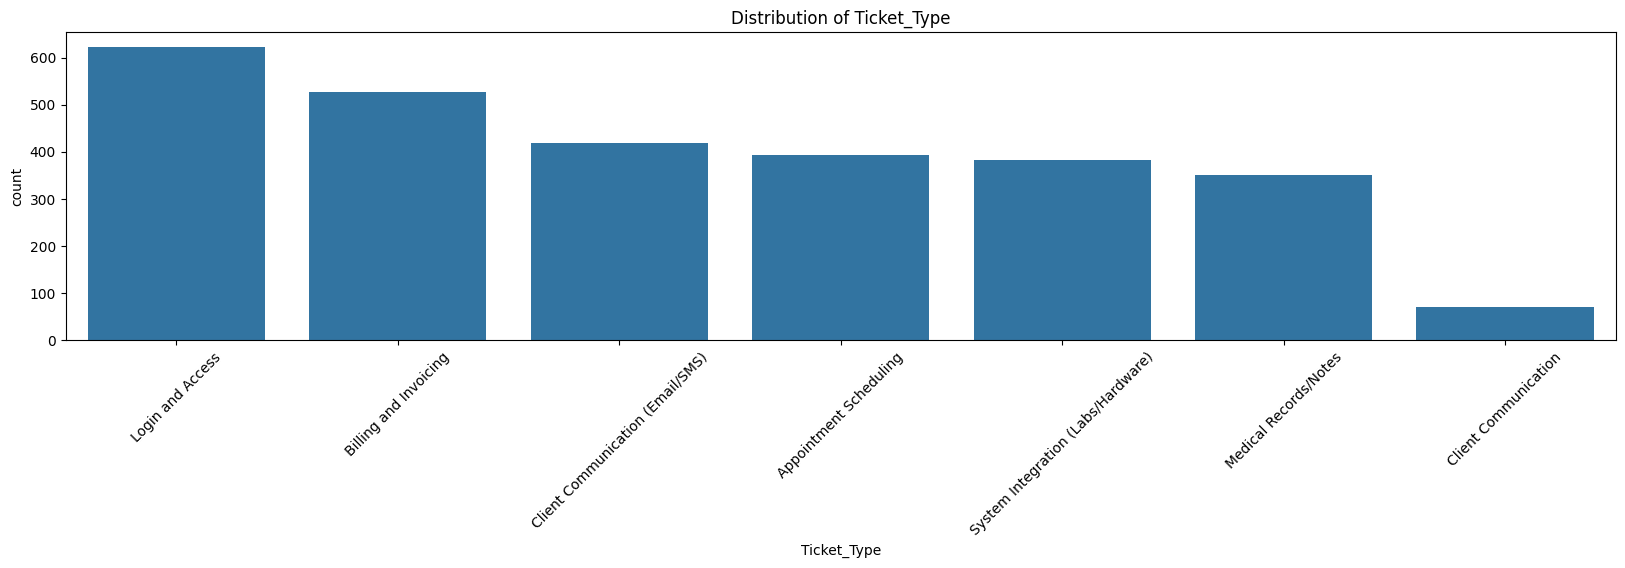

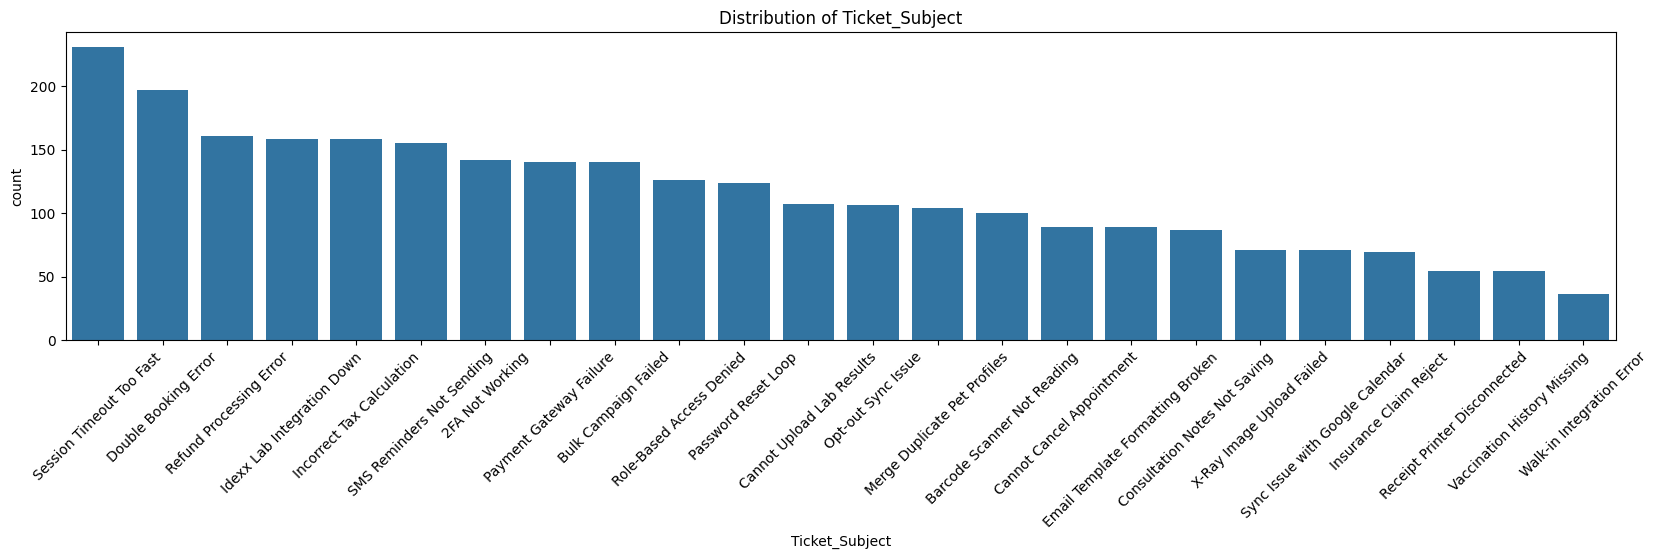

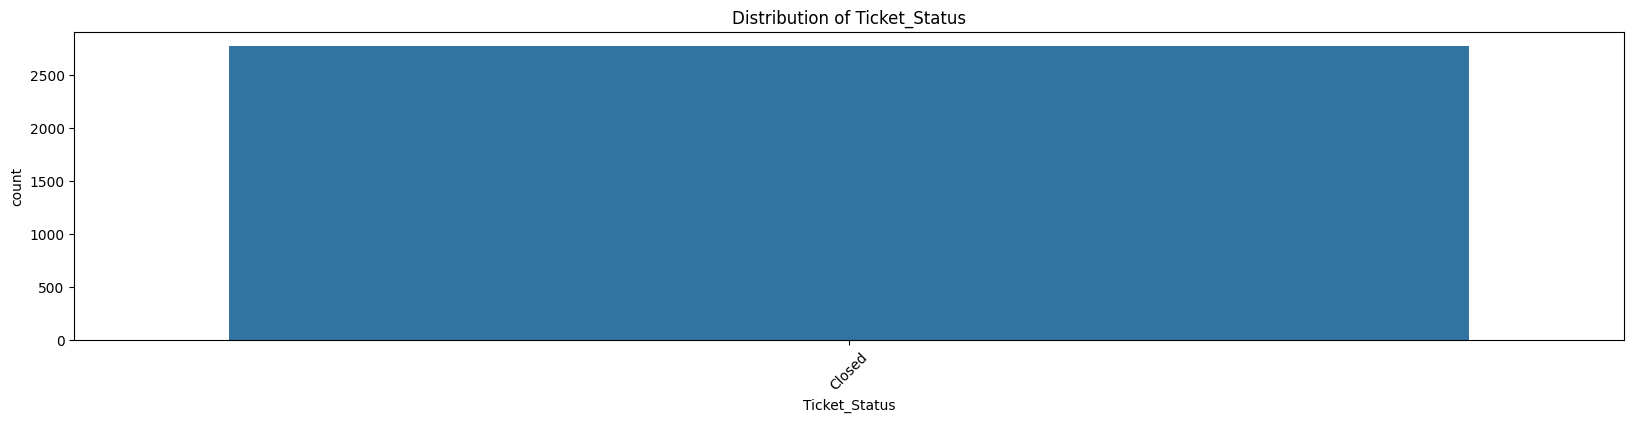

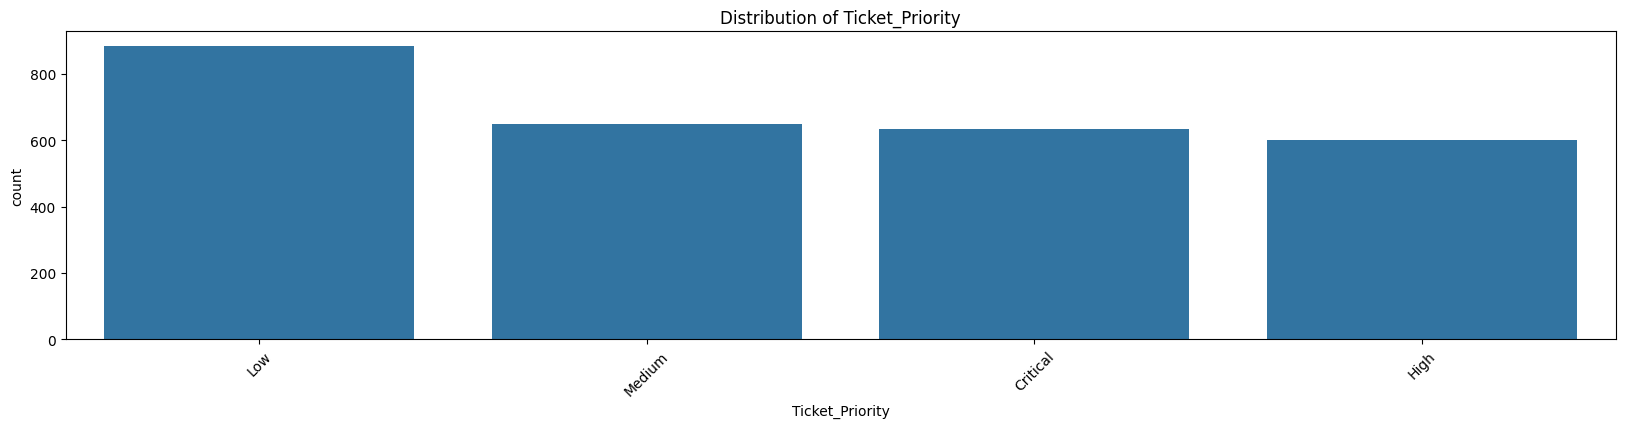

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Ticket_Type', 'Ticket_Subject', 'Ticket_Status', 'Ticket_Priority']

for col in categorical_cols:
    plt.figure(figsize=(20,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


### Text analysis

In [0]:
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.1 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-27e83b88-f435-4967-bb51-c8/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


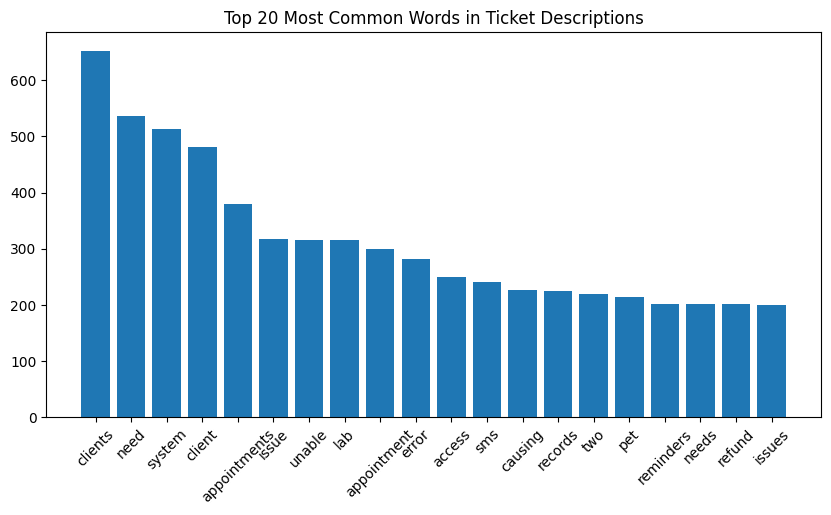

In [0]:
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Combine all issue descriptions
all_text = " ".join(df['Ticket_Description'])

# Tokenize
words = [w for w in all_text.split() if w not in stop_words]

# Most common words
word_freq = Counter(words).most_common(20)

word_df = pd.DataFrame(word_freq, columns=['word', 'count'])
plt.figure(figsize=(10,5))
plt.bar(word_df['word'], word_df['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words in Ticket Descriptions")
plt.show()

### Embedding

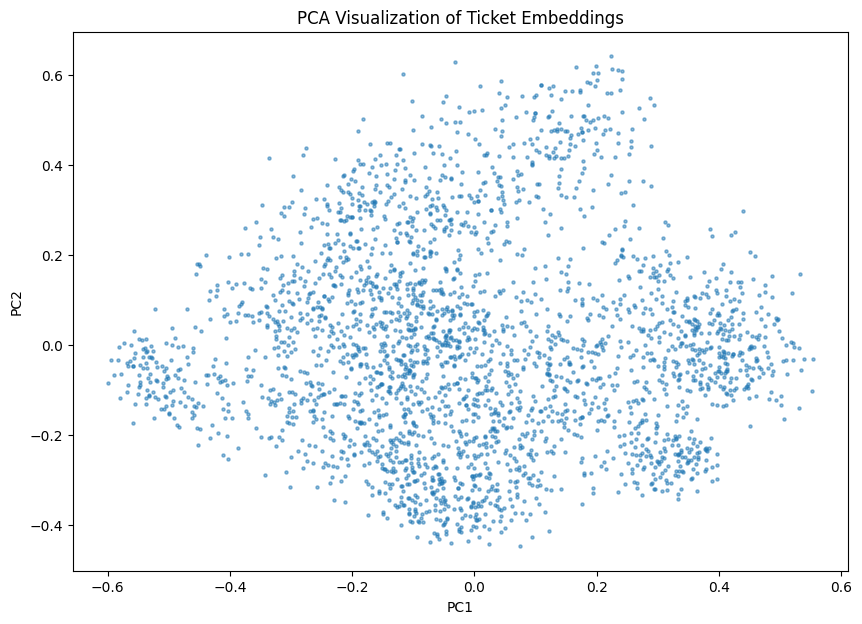

In [0]:
from sklearn.decomposition import PCA

# Convert embeddings column to array
emb_matrix = np.vstack(df['embeddings'].values)

# Reduce to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_matrix)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5, alpha=0.5)
plt.title("PCA Visualization of Ticket Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


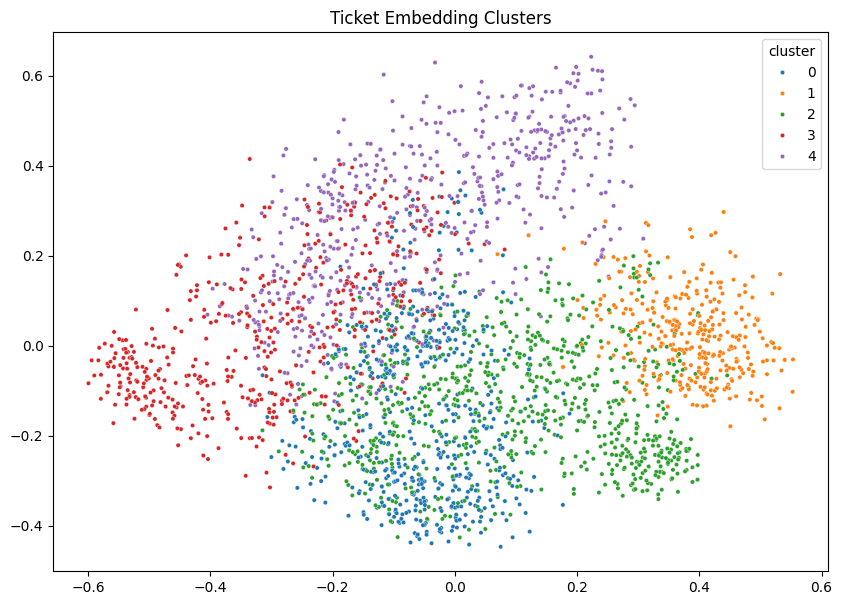


Cluster 0 top words:
[('the', 552), ('a', 510), ('to', 488), ('for', 313), ('is', 297), ('this', 282), ('our', 236), ('client', 220), ('we', 214), ('refund', 199), ('tax', 193), ('clients', 188), ('are', 170), ('an', 167), ('system', 153), ('i', 143), ('payment', 127), ('their', 121), ('and', 115), ('error', 112)]

Cluster 1 top words:
[('the', 379), ('lab', 309), ('to', 306), ('is', 223), ('results', 196), ('upload', 181), ('idexx', 159), ('for', 156), ('we', 140), ('this', 137), ('i', 133), ('our', 131), ('integration', 117), ('a', 106), ('are', 97), ('and', 90), ('not', 89), ('system', 86), ('unable', 80), ('error', 74)]

Cluster 2 top words:
[('the', 905), ('to', 795), ('i', 567), ('is', 495), ('my', 410), ('this', 320), ('a', 255), ('our', 243), ('in', 235), ('access', 197), ('for', 189), ('and', 183), ('not', 183), ('reset', 170), ('are', 169), ('system', 169), ('password', 165), ('session', 151), ('it', 141), ('am', 137)]

Cluster 3 top words:
[('to', 377), ('our', 377), ('this

In [0]:
from sklearn.cluster import KMeans

pca = PCA(n_components=10).fit_transform(emb_matrix)

# Cluster embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(pca)

# Visualize clusters
plt.figure(figsize=(10,7))
sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=df['cluster'], palette='tab10', s=10)
plt.title("Ticket Embedding Clusters")
plt.show()

def top_words_for_cluster(cluster_id, n=20):
    texts = df[df['cluster'] == cluster_id]['Ticket_Description']
    all_words = " ".join(texts).split()
    common = Counter(all_words).most_common(n)
    return common

for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} top words:")
    print(top_words_for_cluster(c))

def sample_tickets(cluster_id, n=5):
    return df[df['cluster'] == cluster_id]['Ticket_Description'].head(n)

for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} sample tickets:")
    print(sample_tickets(c))

In [0]:
# 1. Calculate High Priority Rate
cluster_high_priority = (
    df.groupby('cluster')
      .apply(lambda x: (x['Ticket_Priority'].isin(['High', 'Critical'])).mean(), include_groups=False)
      .sort_values()
)
print("High Priority Rate by Cluster:")
print(cluster_high_priority)

# 2. Utilize the new Minutes to resolve column!
cluster_resolution = df.groupby('cluster')['Minutes_to_resolve'].mean().sort_values()
print("\nMean Minutes to Resolve by Cluster:")
print(cluster_resolution)

High Priority Rate by Cluster:
cluster
1    0.322674
2    0.370417
4    0.460133
0    0.509946
3    0.569937
dtype: float64

Mean Minutes to Resolve by Cluster:
cluster
1    42.136628
0    54.625678
4    60.262458
3    65.473904
2    67.907712
Name: Minutes_to_resolve, dtype: Float64
